# BUSINESS SALES PERFORMANCE ANALYTICS
# BY COLINS NDWIGA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
from datetime import datetime

## Step 1: Loading the Data

 ### I downloaded the dataset from https://www.kaggle.com/datasets/ulrikthygepedersen/online-retail-dataset

In [4]:
df=pd.read_csv('online_retail.csv',low_memory=False)
df = df.drop(columns=['Unnamed: 10', 'Unnamed: 11'])
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Time,UnitPrice,Total Price,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010,08:26:00,2.55,15.30,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010,08:26:00,3.39,20.34,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010,08:26:00,2.75,22.00,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010,08:26:00,3.39,20.34,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010,08:26:00,3.39,20.34,17850.0,United Kingdom


## Step 2: Check Data Types

In [5]:
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Time               str
UnitPrice      float64
Total Price    float64
CustomerID     float64
Country            str
dtype: object

In [13]:
df['CustomerID'] = df['CustomerID'].astype('string')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d/%m/%Y')
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.time

In [14]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Time,UnitPrice,Total Price,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,08:26:00,2.55,15.30,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,08:26:00,3.39,20.34,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,08:26:00,2.75,22.00,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,08:26:00,3.39,20.34,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,08:26:00,3.39,20.34,17850.0,United Kingdom


In [17]:
df['InvoiceDatetime'] = pd.to_datetime(
    df['InvoiceDate'].astype(str) + ' ' + df['Time'].astype(str)
)

## Step 3: Data Cleaning

### Handle Missing Values

In [16]:
# Dropping rows with missing Description 
df = df.dropna(subset=['Description'])

# CustomerID missing = guest / unregistered orders. We keep them for now
# Let's create a flag:
df['IsGuest'] = df['CustomerID'].isna()

print("After dropping missing Description:", df.shape)

After dropping missing Description: (540455, 11)


### Cancellations & Negative Values

In [20]:
# Flag cancellations
df['IsCancellation'] = df['InvoiceNo'].str.startswith('C', na=False)

# Separate or filter as needed
cancellations = df[df['IsCancellation']]
print("Cancellations:", len(cancellations))

# For main analysis, often keep only positive quantity transactions
df_clean = df[~df['IsCancellation']].copy()

# Also remove any remaining negative quantities (should be rare)
df_clean = df_clean[df_clean['Quantity'] > 0]

print("Positive transactions only:", df_clean.shape)

Cancellations: 9288
Positive transactions only: (530693, 13)


In [36]:
df_clean = df_clean[df_clean['UnitPrice'] > 0.01]

In [37]:
# Check problematic UnitPrice values
print("Negative UnitPrice:", len(df_clean[df_clean['UnitPrice'] < 0]))
print("Zero UnitPrice:", len(df_clean[df_clean['UnitPrice'] == 0]))
print("Very small UnitPrice (< 0.01):", len(df_clean[df_clean['UnitPrice'] < 0.01]))

# Show actual examples
print("\nExamples of negative prices:")
print(df_clean[df_clean['UnitPrice'] < 0][['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice']].head())

print("\nExamples of zero prices:")
print(df_clean[df_clean['UnitPrice'] == 0][['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice']].head())

Negative UnitPrice: 0
Zero UnitPrice: 0
Very small UnitPrice (< 0.01): 0

Examples of negative prices:
Empty DataFrame
Columns: [InvoiceNo, StockCode, Description, Quantity, UnitPrice]
Index: []

Examples of zero prices:
Empty DataFrame
Columns: [InvoiceNo, StockCode, Description, Quantity, UnitPrice]
Index: []


In [38]:
df_clean = df_clean[df_clean['Description'] != "?"].copy()

# 2. Remove problematic StockCodes
weird_codes = ['M', 'S', 'm', 's', 'POST', 'DOT', 'C2', 'BANK', 'CRUK', 'AMAZONFEE']
df_clean = df_clean[~df_clean['StockCode'].isin(weird_codes)].copy()

# 3. Handle gift vouchers - Keep them (they are valid revenue)
# Optional: Create a flag if you want
df_clean['IsGiftVoucher'] = df_clean['StockCode'].str.contains('gift_0001', na=False)

### Extracting time features

In [25]:
df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['MonthName'] = df_clean['InvoiceDate'].dt.month_name()
df_clean['DayName'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour'] = pd.to_datetime(df_clean['Time'].astype(str), format='%H:%M:%S').dt.hour

In [27]:
df_clean = df_clean.drop(columns=['Month', 'DayOfWeek'])

In [28]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Time,UnitPrice,Total Price,CustomerID,Country,IsGuest,InvoiceDatetime,IsCancellation,Year,Hour,DayName,MonthName
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,08:26:00,2.55,15.30,17850.0,United Kingdom,False,2010-12-01 08:26:00,False,2010,8,Wednesday,December
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,08:26:00,3.39,20.34,17850.0,United Kingdom,False,2010-12-01 08:26:00,False,2010,8,Wednesday,December
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,08:26:00,2.75,22.00,17850.0,United Kingdom,False,2010-12-01 08:26:00,False,2010,8,Wednesday,December
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,08:26:00,3.39,20.34,17850.0,United Kingdom,False,2010-12-01 08:26:00,False,2010,8,Wednesday,December
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,08:26:00,3.39,20.34,17850.0,United Kingdom,False,2010-12-01 08:26:00,False,2010,8,Wednesday,December


### StockCode cleaning

In [29]:
df_clean = df_clean[~df_clean['StockCode'].str.contains('POST|DOT|C2|BANK', na=False, regex=True)]

### Handling Duplicates

In [31]:
duplicates = df_clean.duplicated().sum()
print("Duplicate rows:", duplicates)
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()

Duplicate rows: 5231


In [39]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Time,UnitPrice,Total Price,CustomerID,Country,IsGuest,InvoiceDatetime,IsCancellation,Year,Hour,DayName,MonthName,IsGiftVoucher
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,08:26:00,2.55,15.30,17850.0,United Kingdom,False,2010-12-01 08:26:00,False,2010,8,Wednesday,December,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,08:26:00,3.39,20.34,17850.0,United Kingdom,False,2010-12-01 08:26:00,False,2010,8,Wednesday,December,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,08:26:00,2.75,22.00,17850.0,United Kingdom,False,2010-12-01 08:26:00,False,2010,8,Wednesday,December,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,08:26:00,3.39,20.34,17850.0,United Kingdom,False,2010-12-01 08:26:00,False,2010,8,Wednesday,December,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,08:26:00,3.39,20.34,17850.0,United Kingdom,False,2010-12-01 08:26:00,False,2010,8,Wednesday,December,False


In [41]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,Total Price,InvoiceDatetime,Year,Hour
count,522569.000000,522569,522569.000000,522569.000000,522569,522569.000000,522569.000000
mean,10.642457,2011-07-04 03:06:13.806330,3.296230,19.631794,2011-07-04 16:40:45.146765,2010.921871,13.075184
min,1.000000,2010-12-01 00:00:00,0.040000,0.060000,2010-12-01 08:26:00,2010.000000,6.000000
25%,1.000000,2011-03-28 00:00:00,1.250000,3.900000,2011-03-28 12:13:00,2011.000000,11.000000
50%,4.000000,2011-07-20 00:00:00,2.080000,9.900000,2011-07-20 11:55:00,2011.000000,13.000000
75%,12.000000,2011-10-19 00:00:00,4.130000,17.700000,2011-10-19 11:44:00,2011.000000,15.000000
max,80995.000000,2011-12-09 00:00:00,11062.060000,168469.600000,2011-12-09 12:50:00,2011.000000,20.000000
std,156.589794,NaN,15.917135,270.362486,NaN,0.268375,2.442459


## Outliers

In [43]:
# High Quantity Outliers
high_qty = df_clean[df_clean['Quantity'] > 1000].copy()
print("Number of rows with Quantity > 1000:", len(high_qty))
print("\nTop high quantity transactions:")
print(high_qty[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 
                'UnitPrice', 'Total Price', 'Country']].sort_values(by='Quantity', ascending=False).head(20))

Number of rows with Quantity > 1000: 104

Top high quantity transactions:
       InvoiceNo StockCode                          Description  Quantity  \
540421    581483     23843          PAPER CRAFT , LITTLE BIRDIE     80995   
61619     541431     23166       MEDIUM CERAMIC TOP STORAGE JAR     74215   
421632    573008     84077    WORLD WAR 2 GLIDERS ASSTD DESIGNS      4800   
206121    554868     22197                 SMALL POPCORN HOLDER      4300   
97432     544612     22053                EMPIRE DESIGN ROSETTE      3906   
270885    560599     18007  ESSENTIAL BALM 3.5g TIN IN ENVELOPE      3186   
52711     540815     21108   FAIRY CAKE FLANNEL ASSORTED COLOUR      3114   
160546    550461     21108   FAIRY CAKE FLANNEL ASSORTED COLOUR      3114   
433788    573995     16014          SMALL CHINESE STYLE SCISSOR      3000   
291249    562439     84879        ASSORTED COLOUR BIRD ORNAMENT      2880   
4945      536830     84077    WORLD WAR 2 GLIDERS ASSTD DESIGNS      2880   
20

In [44]:
df_clean = df_clean[df_clean['Quantity'] < 10000].copy()

In [49]:
# High UnitPrice Outliers
high_price = df_clean[df_clean['UnitPrice'] > 300].copy()
print("Number of rows with UnitPrice > 300:", len(high_price))
print("\nHigh price transactions:")
print(high_price[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 
                  'UnitPrice', 'Total Price', 'Country']].sort_values(by='UnitPrice', ascending=False))

Number of rows with UnitPrice > 300: 3

High price transactions:
       InvoiceNo StockCode                     Description  Quantity  \
299982   A563185         B                 Adjust bad debt         1   
222680    556444     22502  PICNIC BASKET WICKER 60 PIECES        60   
222682    556446     22502  PICNIC BASKET WICKER 60 PIECES         1   

        UnitPrice  Total Price         Country  
299982   11062.06     11062.06  United Kingdom  
222680     649.50     38970.00  United Kingdom  
222682     649.50       649.50  United Kingdom  


In [50]:
df_clean = df_clean[df_clean['UnitPrice'] <= 300].copy()

In [51]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,Total Price,InvoiceDatetime,Year,Hour
count,522564.000000,522564,522564.000000,522564.000000,522564,522564.000000,522564.000000
mean,10.345424,2011-07-04 03:06:16.889338,3.272601,19.064904,2011-07-04 16:40:48.248789,2010.921870,13.075189
min,1.000000,2010-12-01 00:00:00,0.040000,0.060000,2010-12-01 08:26:00,2010.000000,6.000000
25%,1.000000,2011-03-28 00:00:00,1.250000,3.900000,2011-03-28 12:13:00,2011.000000,11.000000
50%,4.000000,2011-07-20 00:00:00,2.080000,9.900000,2011-07-20 11:55:00,2011.000000,13.000000
75%,12.000000,2011-10-19 00:00:00,4.130000,17.700000,2011-10-19 11:44:00,2011.000000,15.000000
max,4800.000000,2011-12-09 00:00:00,295.000000,7144.720000,2011-12-09 12:50:00,2011.000000,20.000000
std,37.853041,NaN,4.210372,65.300120,NaN,0.268377,2.442457


In [52]:
df_clean = df_clean[df_clean['UnitPrice'] >= 0.10].copy()

In [53]:
print("Current shape:", df_clean.shape)

Current shape: (522332, 18)


# Step 4: Save The Cleaned Dataset

In [54]:
save_path = r'C:\Users\user\PycharmProjects\pythonProject4\online_retail_cleaned.csv'
df_clean.to_csv(save_path, index=False)

print(f"Cleaned file saved at:\n{save_path}")

Cleaned file saved at:
C:\Users\user\PycharmProjects\pythonProject4\online_retail_cleaned.csv


# Step 5: Exploratory Data Analysis (EDA)

In [55]:
import seaborn as sns
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

### Rename Total Price column to TotalAmount

In [56]:
if 'Total Price' in df_clean.columns:
    df_clean = df_clean.rename(columns={'Total Price': 'TotalAmount'})
    print("Column renamed successfully: 'Total Price' to 'TotalAmount'")
else:
    print("Column 'Total Price' not found. Checking current columns...")

Column renamed successfully: 'Total Price' to 'TotalAmount'


In [57]:
df_clean.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Time,UnitPrice,TotalAmount,CustomerID,Country,IsGuest,InvoiceDatetime,IsCancellation,Year,Hour,DayName,MonthName,IsGiftVoucher
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,08:26:00,2.55,15.30,17850.0,United Kingdom,False,2010-12-01 08:26:00,False,2010,8,Wednesday,December,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,08:26:00,3.39,20.34,17850.0,United Kingdom,False,2010-12-01 08:26:00,False,2010,8,Wednesday,December,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,08:26:00,2.75,22.00,17850.0,United Kingdom,False,2010-12-01 08:26:00,False,2010,8,Wednesday,December,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,08:26:00,3.39,20.34,17850.0,United Kingdom,False,2010-12-01 08:26:00,False,2010,8,Wednesday,December,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,08:26:00,3.39,20.34,17850.0,United Kingdom,False,2010-12-01 08:26:00,False,2010,8,Wednesday,December,False


In [58]:
print("\nDate range:", df_clean['InvoiceDate'].min(), "to", df_clean['InvoiceDate'].max())
print("Total Revenue: £", round(df_clean['TotalAmount'].sum(), 2))


Date range: 2010-12-01 00:00:00 to 2011-12-09 00:00:00
Total Revenue: £ 9960929.64


### Total Sales Revenue reached up to £ 9960929.64

# 1.Products that generate the most revenue

In [59]:
# Top Products by Revenue
top_products = df_clean.groupby(['StockCode', 'Description'])['TotalAmount'].agg(
    ['sum', 'count', 'mean']
).rename(columns={'sum':'Revenue', 'count':'Quantity_Sold', 'mean':'Avg_Price'}).reset_index()

top_products = top_products.sort_values('Revenue', ascending=False)

print("TOP 15 PRODUCTS BY REVENUE")
print(top_products.head(15)[['Description', 'Revenue', 'Quantity_Sold', 'Avg_Price']])

TOP 15 PRODUCTS BY REVENUE
                             Description    Revenue  Quantity_Sold   Avg_Price
1340            REGENCY CAKESTAND 3 TIER  174156.54           2007   86.774559
3638  WHITE HANGING HEART T-LIGHT HOLDER  104284.24           2244   46.472478
2875                       PARTY BUNTING   99445.23           1699   58.531624
3617             JUMBO BAG RED RETROSPOT   94159.81           2109   44.646662
2028                  RABBIT NIGHT LIGHT   66870.03           1017   65.752242
1022     PAPER CHAIN KIT 50'S CHRISTMAS    64875.59           1184   54.793573
3414       ASSORTED COLOUR BIRD ORNAMENT   58927.62           1476   39.923862
3057                       CHILLI LIGHTS   54096.36            667   81.103988
2284                      SPOTTY BUNTING   42513.48           1154   36.840104
1307             JUMBO BAG PINK POLKADOT   42401.01           1232   34.416404
397             BLACK RECORD COVER FRAME   40633.38            376  108.067500
2268       DOORMAT KEEP C

## Plotting

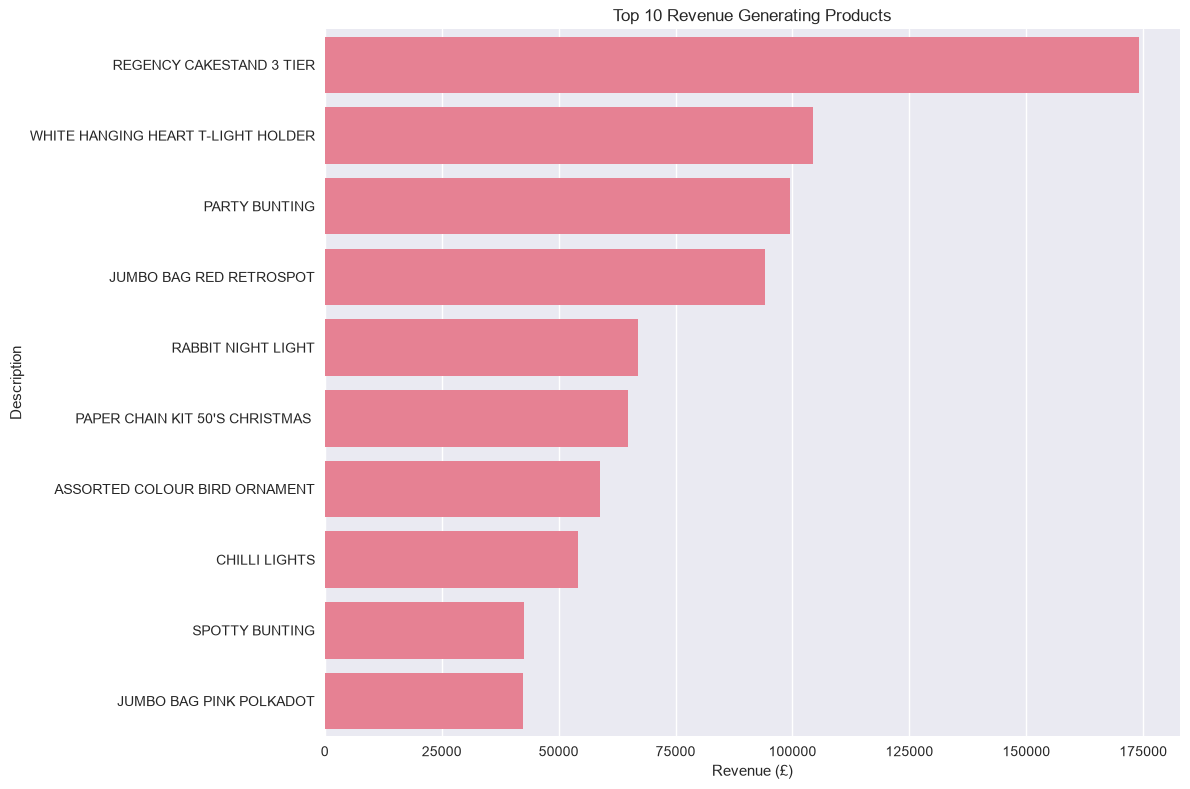

In [60]:
plt.figure(figsize=(12, 8))
sns.barplot(data=top_products.head(10), x='Revenue', y='Description')
plt.title('Top 10 Revenue Generating Products')
plt.xlabel('Revenue (£)')
plt.tight_layout()
plt.show()

### Key Insights
### TOP PERFORMING PRODUCTS
### • REGENCY CAKESTAND 3 TIER is the clear star performer (£174,156)
### • WHITE HANGING HEART T-LIGHT HOLDER and PARTY BUNTING also exceeded £100k
### • These 3 products alone generated significant revenue — strong brand recognition.

# 2.Revenue Trends Over Time

In [67]:
# Monthly Revenue Trend
monthly_revenue = df_clean.groupby('MonthName')['TotalAmount'].sum().reset_index().sort_values('TotalAmount', ascending=False)
monthly_revenue['MonthName'] = monthly_revenue['MonthName'].astype(str)
print(monthly_revenue.tail(12))

    MonthName  TotalAmount
9    November   1451995.12
2    December   1221710.01
10    October   1103114.12
11  September   1028155.62
8         May    740032.49
1      August    724219.68
6        June    697647.87
7       March    689839.92
5        July    687816.75
4     January    593255.86
0       April    515419.66
3    February    507722.54


### Plotting

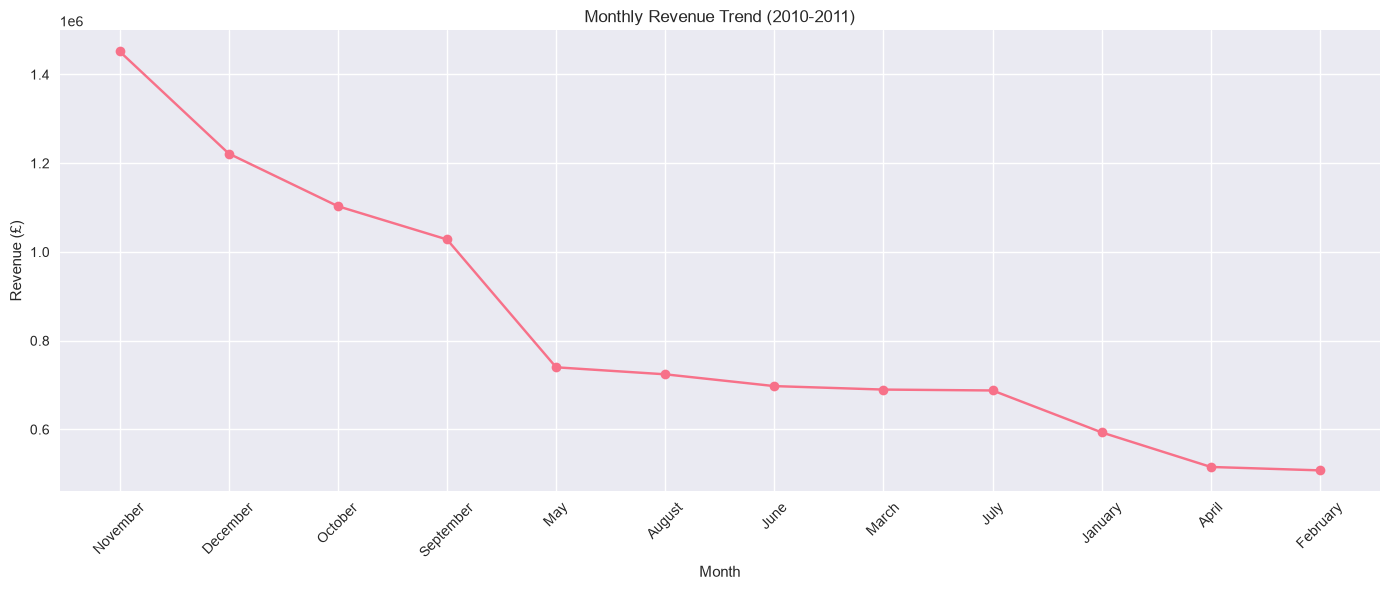

In [68]:
plt.figure(figsize=(14, 6))
plt.plot(monthly_revenue['MonthName'], monthly_revenue['TotalAmount'], marker='o')
plt.title('Monthly Revenue Trend (2010-2011)')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Key Insight
### SEASONALITY & REVENUE TRENDS
### • Strong Christmas effect: November (£1.45M) and December (£1.22M) dominate
### • Clear upward trend in the last 4 months of the year (Sep–Dec)
### • Lowest sales in February — typical post-Christmas dip.

In [80]:
# Group by DayName
day_revenue = df_clean.groupby('DayName')['TotalAmount'].agg(
    ['sum', 'count', 'mean']
).rename(columns={
    'sum': 'Revenue',
    'count': 'Number_of_Transactions',
    'mean': 'Avg_Revenue_per_Transaction'
}).reset_index()

# Order the days correctly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday'] # Saturdays do not Record Sales. Business may be closed
day_revenue['DayName'] = pd.Categorical(day_revenue['DayName'], categories=day_order, ordered=True)
day_revenue = day_revenue.sort_values('DayName')

print("REVENUE PERFORMANCE BY DAY OF WEEK")
print(day_revenue.round(2))

REVENUE PERFORMANCE BY DAY OF WEEK
     DayName     Revenue  Number_of_Transactions  Avg_Revenue_per_Transaction
1     Monday  1682801.95                   91993                        18.29
4    Tuesday  2007616.36                   98219                        20.44
5  Wednesday  1782156.38                   91037                        19.58
3   Thursday  2131224.44                   99701                        21.38
0     Friday  1559062.61                   79206                        19.68
2     Sunday   798067.90                   62176                        12.84


### Plotting

C:\Users\user\AppData\Local\Temp\ipykernel_632\2197760676.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=day_revenue, x='DayName', y='Revenue', palette='viridis')
C:\Users\user\AppData\Local\Temp\ipykernel_632\2197760676.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=day_revenue, x='DayName', y='Avg_Revenue_per_Transaction', palette='magma')


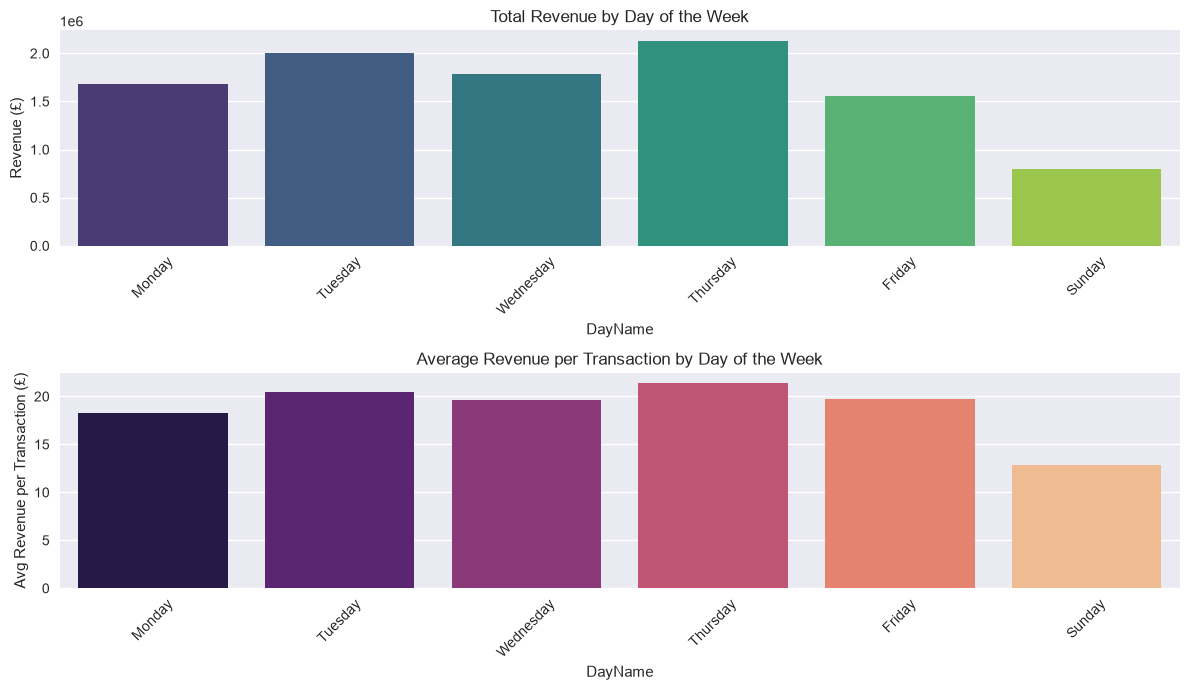

In [76]:
plt.figure(figsize=(12, 7))

# Bar plot - Total Revenue
plt.subplot(2, 1, 1)
sns.barplot(data=day_revenue, x='DayName', y='Revenue', palette='viridis')
plt.title('Total Revenue by Day of the Week')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)

# Line plot - Average Revenue per Transaction
plt.subplot(2, 1, 2)
sns.barplot(data=day_revenue, x='DayName', y='Avg_Revenue_per_Transaction', palette='magma')
plt.title('Average Revenue per Transaction by Day of the Week')
plt.ylabel('Avg Revenue per Transaction (£)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Key Insights
### WEEKDAY PERFORMANCE
### • Thursday is the strongest sales day (£2.13M)
### • Tuesday and Wednesday also perform very well
### • Sunday has the lowest revenue — business may be closed or have reduced operations.
### • Business Remains Closed on Saturdays, so no explained Sales

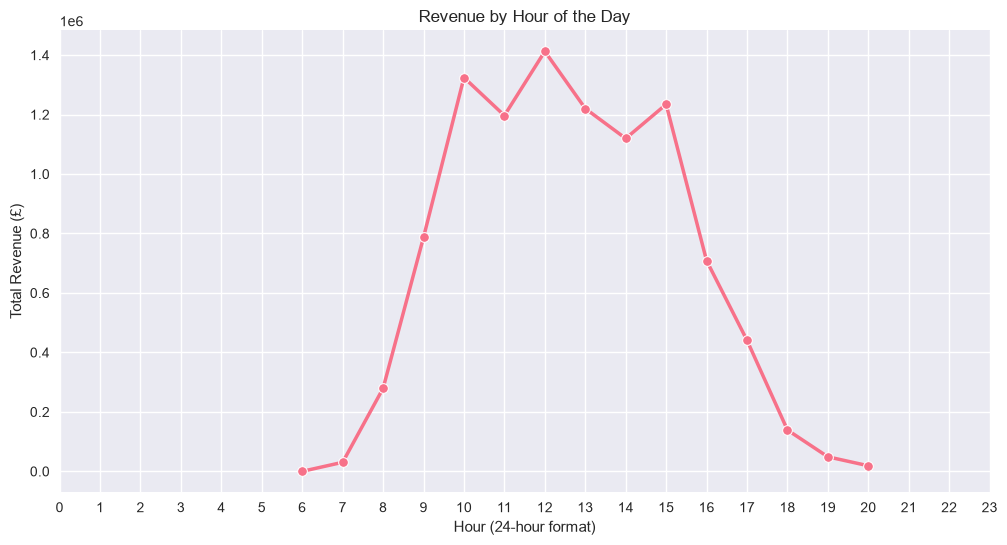

In [81]:
# Revenue by Hour
hour_revenue = df_clean.groupby('Hour')['TotalAmount'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=hour_revenue, x='Hour', y='TotalAmount', marker='o', linewidth=2.5)
plt.title('Revenue by Hour of the Day')
plt.xlabel('Hour (24-hour format)')
plt.ylabel('Total Revenue (£)')
plt.grid(True)
plt.xticks(range(0, 24))
plt.show()

### Key Insight
### HOURLY SALES PATTERN
### • Sales start rising sharply from 8 AM
### • Peak performance between "11 AM – 1 PM"(lunchtime shopping)
### • Secondary peak around 3–4 PM
### • Very low activity before 7 AM and after 8 PM
### • This suggests the majority of customers shop during "midday".

# 3.Most Profitable Regions (Revenue Performance by Country)


In [69]:
country_revenue = df_clean.groupby('Country')['TotalAmount'].agg(
    ['sum', 'count']
).rename(columns={'sum':'Revenue', 'count':'Transactions'}).sort_values('Revenue', ascending=False)

print("TOP 10 COUNTRIES BY REVENUE")
print(country_revenue.head(10))



TOP 10 COUNTRIES BY REVENUE
                   Revenue  Transactions
Country                                 
United Kingdom  8438269.19        478690
Netherlands      283889.34          2322
EIRE             270808.94          7758
Germany          205335.71          8634
France           184470.92          8082
Australia        138103.81          1180
Spain             55706.56          2417
Switzerland       53065.60          1927
Japan             37416.37           321
Belgium           36927.34          1935


### Plotting

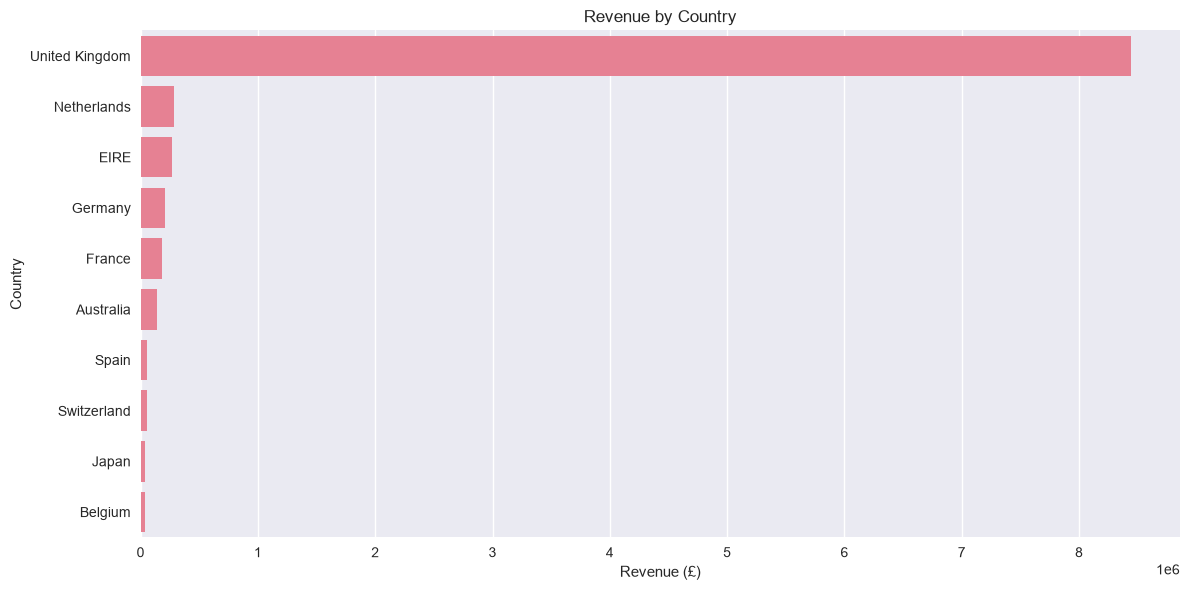

In [70]:
plt.figure(figsize=(12, 6))
sns.barplot(data=country_revenue.head(10), x='Revenue', y=country_revenue.head(10).index)
plt.title('Revenue by Country')
plt.xlabel('Revenue (£)')
plt.tight_layout()
plt.show()

### Key Insight
### The United Kingdom is the highest Country by revenue, with up to  £ 8438269.19, having up to 478690 transactions.
### Other top countries contributing to Revenue are the Netherlands, the Republic of Ireland (EIRE), Germany, France, and Australia

# Step 6: Recommendations

## 1. Product Strategy
### - Focus marketing and inventory on the Top 10 products (especially REGENCY CAKESTAND)
### - Create bundles around high performers (e.g., Cake Stand + Party Bunting)
### - Consider introducing more premium/luxury variants of top sellers

## 2. Seasonality & Inventory
### - Ramp up stock significantly from September onwards
### - Plan major promotions in November (pre-Christmas)
### - Develop post-Christmas clearance strategy for February

## 3. Operational Improvements
### - Ensure maximum staffing and stock availability on **Thursdays**
### - Optimize operations for peak hours (11 AM – 1 PM)
### - Consider extending hours or targeted promotions on Sundays to lift performance

## 4. Geographic Expansion
### - UK is dominant (84% of revenue) — maintain strong focus here
### - Netherlands, Republic of Ireland, Germany, and France show strong potential — target these for growth
### - Explore localized marketing campaigns in high-potential European markets

## 5. Customer & Growth Opportunities
### - Develop a loyalty program for high-frequency customers
### - Target wholesale/B2B customers (many large quantity orders exist)
### - Explore gift voucher promotions (you already have gift_0001 entries)

## 6. Immediate Impact Recommendations 
### - Reduce dependency on a few top products by promoting complementary items
### - Run targeted email campaigns during peak hours/days